# **1. Alexnet**
AlexNet은 2012년 ILSVRC(ImageNet Large Scale Visual Recognition Challenge)에서 우승한 딥러닝 모델로, 딥러닝의 대중화를 이끈 중요한 합성곱 신경망(CNN)입니다. 이 모델은 8개의 레이어(5개의 합성곱 레이어와 3개의 완전 연결 레이어)로 구성되어 있으며, ReLU 활성화 함수, 드롭아웃(dropout), 데이터 증강(data augmentation) 등을 사용해 과적합을 방지하고 학습 성능을 향상시켰습니다. AlexNet은 대규모 데이터셋과 GPU 병렬 연산을 활용해 1,000개의 클래스 분류 문제에서 top-1, top-5 error rates가 각각 37.5%, 17.5%로 뛰어난 성능을 보여, 컴퓨터 비전에서 딥러닝이 표준 기법으로 자리 잡는 데 기여했습니다. 이 성과는 당시 기준으로 매우 뛰어난 결과였습니다. 특히 AlexNet은 이전에 사용된 전통적인 머신러닝 방법론보다 훨씬 큰 차이로 성능을 끌어올리며, 딥러닝의 가능성을 보여주었습니다. [[논문 링크](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)]

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fdcw1wn%2FbtsLNY2WjZf%2FAAAAAAAAAAAAAAAAAAAAAP7fPOYRu3K_vGkWg8DhH8_YK3QIw1BDmMrUdbFO-Kvf%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1769871599%26allow_ip%3D%26allow_referer%3D%26signature%3DwUf%252FNIapmlvmRvSjug0%252F5KkI7Nc%253D'>

### ※ ImageNet LSVRC

ImageNet LSVRC는 Large Scale Visual Recognition Challenge의 약자로, 이미지 인식 및 분류 기술을 겨루는 대회입니다. 2010년부터 매년 개최되었으며, ImageNet이라는 대규모 이미지 데이터셋을 기반으로 참가자들이 다양한 모델을 설계하고 경쟁했습니다.

- ImageNet 데이터셋: 약 1400만 장의 이미지를 포함하며, 1000개의 클래스(예: 고양이, 강아지, 자동차 등)로 분류된 대규모 이미지 데이터셋입니다.
- 목적: 컴퓨터 비전 및 딥러닝 기술의 발전을 촉진하고, 이미지 인식 분야에서 혁신적인 기술을 발견하는 것이 목표였습니다.
- LSVRC-2010: 이 대회에서 AlexNet이 2012년에 처음으로 딥러닝 기반 접근법을 사용해 뛰어난 성능을 보여줌으로써 딥러닝의 새로운 시대를 열었습니다.

### 1. Top-1 Error Rate
- 모델이 예측한 가장 높은 확률의 클래스(Top-1)가 정답이 아닐 확률입니다.
- 예를 들어, 이미지에 "고양이"가 있고, 모델이 가장 높은 확률로 "강아지"라고 예측했다면, 이건 Top-1 에러입니다.​

### 2. Top-5 Error Rate
- 모델이 예측한 상위 5개의 클래스 중 하나라도 정답에 포함되지 않았을 확률입니다.
- 예를 들어, 이미지가 "고양이"인데 모델이 "강아지", "토끼", "고양이", "호랑이", "여우"를 상위 5개로 예측했다면, 이건 정답으로 간주됩니다.
- Top-5를 사용하는 이유: 사람이 보기에 유사한 클래스(예: 치타와 표범)를 분류하는 것은 어렵기 때문에, 상위 5개 중에 정답이 있는지를 확인하는 방식으로 보다 실용적인 성능을 평가합니다.

# **2. CIFAR 데이터셋**
CIFAR 데이터셋은 torchvision 라이브러리에서 제공하는 이미지 데이터셋으로, 주로 딥러닝 모델의 학습 및 평가에 사용됩니다. CIFAR-10과 CIFAR-100 두 종류가 있으며, 각각 10개와 100개의 클래스에 대해 32x32 크기의 컬러 이미지로 구성됩니다. CIFAR-10은 클래스당 6,000개(총 60,000개)의 이미지로 이루어져 있으며, CIFAR-100은 클래스당 600개(총 60,000개)로 구성됩니다. PyTorch는 torchvision.datasets 모듈을 통해 이 데이터셋을 쉽게 불러올 수 있으며, 학습/테스트 데이터셋 분리, 데이터 증강(transforms), 정규화 등의 전처리를 지원합니다. 이 데이터셋은 이미지 분류 알고리즘을 실험하고 비교하는 데 널리 사용됩니다.

# **3. Alexnet 직접 구현(CIFAR 데이터셋 사용)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch import nn
from torchvision import datasets
from torchvision.transforms import transforms
from torchvision.transforms.functional import to_pil_image

In [2]:
train_img = datasets.CIFAR10(
    root = 'data',
    train = True,
    download = True,
    transform = transforms.ToTensor(),
)

test_img = datasets.CIFAR10(
    root = 'data',
    train = False,
    download = True,
    transform = transforms.ToTensor(),
)

100%|██████████| 170M/170M [00:04<00:00, 42.5MB/s]


In [3]:
mean = train_img.data.mean(axis=(0, 1, 2)) / 255
std = train_img.data.std(axis=(0, 1, 2)) / 255
print(f'평균:{mean}, 표준편차:{std}')

평균:[0.49139968 0.48215841 0.44653091], 표준편차:[0.24703223 0.24348513 0.26158784]


In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(size=train_img.data.shape[1], padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [5]:
train_img = datasets.CIFAR10(
    root = 'data',
    train = True,
    download = True,
    transform = transform_train,
)

test_img = datasets.CIFAR10(
    root = 'data',
    train = False,
    download = True,
    transform = transform_test,
)

In [6]:
EPOCH = 10
BATCH_SIZE = 128
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using Devie: ", DEVICE)

Using Devie:  cuda


In [7]:
train_loader = DataLoader(train_img, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_img, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
print(train_img, '\n ----------------- \n', test_img)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.49139968 0.48215841 0.44653091], std=[0.24703223 0.24348513 0.26158784])
           ) 
 ----------------- 
 Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.49139968 0.48215841 0.44653091], std=[0.24703223 0.24348513 0.26158784])
           )


In [9]:
train_img[0]

(tensor([[[-1.9892, -1.9892, -1.9892,  ..., -1.9892, -1.9892, -1.9892],
          [-1.9892, -1.9892, -1.9892,  ...,  0.6777,  0.5349,  0.5190],
          [-1.9892, -1.9892, -1.9892,  ...,  0.1063,  0.1221,  0.1221],
          ...,
          [-1.9892, -1.9892, -1.9892,  ...,  0.0269, -0.1795,  0.9635],
          [-1.9892, -1.9892, -1.9892,  ..., -0.5605, -1.1955,  0.1856],
          [-1.9892, -1.9892, -1.9892,  ..., -1.0685, -1.4495,  0.0904]],
 
         [[-1.9802, -1.9802, -1.9802,  ..., -1.9802, -1.9802, -1.9802],
          [-1.9802, -1.9802, -1.9802,  ...,  0.2102,  0.0974,  0.1135],
          [-1.9802, -1.9802, -1.9802,  ..., -0.5146, -0.4663, -0.4341],
          ...,
          [-1.9802, -1.9802, -1.9802,  ..., -0.3535, -0.5790,  0.5162],
          [-1.9802, -1.9802, -1.9802,  ..., -0.8689, -1.5937, -0.2891],
          [-1.9802, -1.9802, -1.9802,  ..., -1.4810, -1.8997, -0.4663]],
 
         [[-1.7070, -1.7070, -1.7070,  ..., -1.7070, -1.7070, -1.7070],
          [-1.7070, -1.7070,

In [10]:
train_features, train_labels = next(iter(train_loader))
print(f'Feature batch shape: {train_features.size()}')
print(f'Feature train_labels shape: {train_labels.size()}')

Feature batch shape: torch.Size([128, 3, 32, 32])
Feature train_labels shape: torch.Size([128])


In [11]:
labels_map = {
    0: "plane",
    1: "car",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

In [12]:
def denormalize(img, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img * std + mean

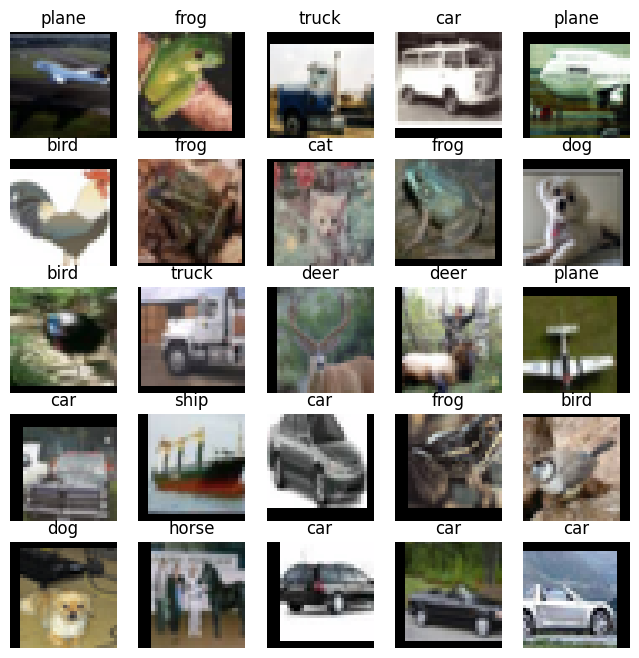

In [13]:
figure = plt.figure(figsize = (8, 8))
cols, rows = 5, 5

for i in range(1, cols * rows +1):
    sample_idx = torch.randint(len(train_img), size=(1,)).item()
    img, label = train_img[sample_idx]
    img = denormalize(img, mean, std)  # Normalize 복원
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis('off')
    plt.imshow(to_pil_image(img))
plt.show()

In [21]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()

        # (128, 3, 32, 32)
        # (batch_size, C, H, W)
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, stride=1, padding=1),
            # inplace=False, 입력 x는 그대로 두고, 새로운 메모리에 결과 y를 반환
            # inplace=True, 입력 x는 직접 수정할 수 있음, 새로운 메모리를 만들지 않음
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(96, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 4096),
            nn.Dropout(0.5),
            nn.ReLU(inplace=True),

            nn.Linear(4096, 4096),
            nn.Dropout(0.5),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x) # (batch_size, C, H, W)
        x = x.view(x.size(0), -1) # C * H * W
        x = self.classifier(x)
        return x

In [22]:
model = AlexNet().to(DEVICE)
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=4096, out_features=4096, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU(inplace=True)
    (3): Linear(in_feature

In [23]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [24]:
def train(train_loader, model, loss_fn, optimizer):
    model.train()

    size = len(train_loader.dataset)

    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(DEVICE), y.to(DEVICE)
        pred = model(X)

        # 손실 계산
        loss = loss_fn(pred, y)

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f'loss: {loss:>7f}  [{current:>5d}]/{size:5d}')

In [25]:
def test(test_loader, model, loss_fn):
    model.eval()

    size = len(test_loader.dataset)
    num_batches = len(test_loader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:8f}\n")

In [26]:
for i in range(EPOCH) :
    print(f"Epoch {i+1} \n------------------------")
    train(train_loader, model, loss, optimizer)
    test(test_loader, model, loss)
print("Done!")

Epoch 1 
------------------------
loss: 2.302187  [    0]/50000
loss: 1.975645  [12800]/50000
loss: 1.793241  [25600]/50000
loss: 1.566050  [38400]/50000
Test Error: 
 Accuracy: 45.0%, Avg loss: 1.472715

Epoch 2 
------------------------
loss: 1.623104  [    0]/50000
loss: 1.429986  [12800]/50000
loss: 1.502852  [25600]/50000
loss: 1.552170  [38400]/50000
Test Error: 
 Accuracy: 54.0%, Avg loss: 1.230497

Epoch 3 
------------------------
loss: 1.118203  [    0]/50000
loss: 1.283623  [12800]/50000
loss: 1.295340  [25600]/50000
loss: 1.315666  [38400]/50000
Test Error: 
 Accuracy: 58.9%, Avg loss: 1.129111

Epoch 4 
------------------------
loss: 1.013061  [    0]/50000
loss: 0.950688  [12800]/50000
loss: 1.216733  [25600]/50000
loss: 1.242835  [38400]/50000
Test Error: 
 Accuracy: 62.7%, Avg loss: 1.048616

Epoch 5 
------------------------
loss: 0.928730  [    0]/50000
loss: 1.185095  [12800]/50000
loss: 1.137644  [25600]/50000
loss: 1.047708  [38400]/50000
Test Error: 
 Accuracy: 67

In [27]:
import itertools

# cm: 혼동행렬
# target_names: 클래스 이름 리스트
# cmap: 컬러맵
# normalize: True -> normalize(0~1), False -> X(그대로)
# labels: True면 각 칸에 숫자를 표기
# title: 제목
def plot_confusion_matrix(cm, target_names=None, cmap=None,
                          normalize=True, labels=True, title='Confusion matrix'):
    # np.trace(cm): 대각선의 합, 정답을 정답으로 맞춘 개수
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy # 오분류율

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    if normalize:
        # np.newaxis: 새로운 차원 추가
        # [:, np.newaxis]: shape를 (num_classes, ) -> (num_classes, 1)
        # 결과: 각 행을 그 행의 합으로 나눔 ->
        # "정답이 A인 데이터 중에서 A로 예측한 비율, B로 예측한 비율"로 바뀜
        # 예) 정답이 고양이인 샘플이 100개
        # 고양이로 80, 강아지로 20 예측했다면 row가 [0.8, 0.2] 표현
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names)
        plt.yticks(tick_marks, target_names)

    if labels:
        # itertools.product(A, B)는 이중 for문과 동일
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            if normalize:
                plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")
            else:
                plt.text(j, i, "{:,}".format(cm[i, j]),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f};\
                         misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

In [28]:
from sklearn.metrics import confusion_matrix

In [29]:
model.eval()
ylabel = []
ypred_label = []

for batch_idx, (inputs, targets) in enumerate(test_loader):
    inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
    outputs = model(inputs)
    _, predicted = outputs.max(1)
    ylabel = np.concatenate((ylabel, targets.cpu().numpy()))
    ypred_label = np.concatenate((ypred_label, predicted.cpu().numpy()))

cnf_matrix = confusion_matrix(ylabel, ypred_label)

In [30]:
cnf_matrix

array([[770,  15,  87,   7,  20,   4,  10,  11,  56,  20],
       [ 30, 828,   6,   3,   3,   4,  18,   5,  25,  78],
       [ 41,   1, 717,  23,  84,  46,  49,  30,   7,   2],
       [ 21,   2, 105, 491,  68, 165,  85,  38,  12,  13],
       [ 18,   2,  76,  38, 743,  20,  44,  57,   1,   1],
       [  7,   0,  76, 113,  51, 673,  24,  53,   2,   1],
       [  6,   1,  67,  27,  51,  14, 830,   2,   2,   0],
       [  9,   2,  67,  29,  54,  35,   2, 800,   0,   2],
       [ 73,  16,  23,  10,   5,   4,   5,   3, 843,  18],
       [ 42,  61,   9,  11,   3,   2,  16,  21,  20, 815]])

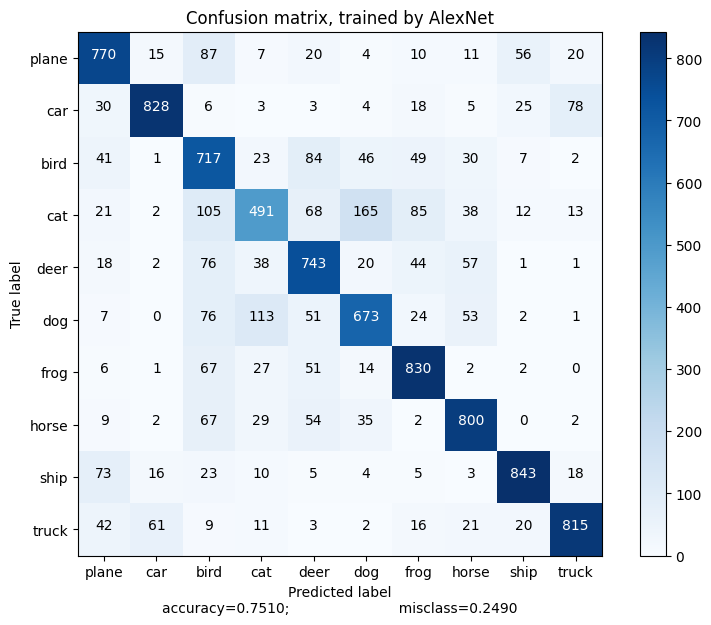

In [32]:
plot_confusion_matrix(cnf_matrix,
                      target_names=labels_map.values(),
                      title='Confusion matrix, trained by AlexNet', normalize=False)